# ACC102 Track 2 Project

## Problem
This project analyses and compares the profitability and growth of Tesla, Ford, and General Motors to help individual investors evaluate which company offers better investment potential.

In [1]:
import wrds
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
db = wrds.Connection()

Enter your WRDS username [juseo]: juwonlee
Enter your password: ········


WRDS recommends setting up a .pgpass file.


Create .pgpass file now [y/n]?:  n


You can create this file yourself at any time with the create_pgpass_file() function.
Loading library list...
Done


In [3]:
libraries = db.list_libraries()
libraries[:10]

['aha_sample',
 'ahasamp',
 'auditsmp',
 'auditsmp_all',
 'bank',
 'bank_all',
 'bank_premium_samp',
 'banksamp',
 'block',
 'block_all']

In [4]:
from sqlalchemy import text

def run_query(query):
    result = db.connection.execute(text(query))
    return pd.DataFrame(result.fetchall(), columns=result.keys())

In [5]:
company_query = """
SELECT gvkey, conm
FROM comp.company
WHERE conm = 'TESLA INC'
   OR conm = 'FORD MOTOR CO'
   OR conm = 'GENERAL MOTORS CO'
"""

company_data = run_query(company_query)
company_data

,gvkey,conm
0,004839,FORD MOTOR CO
1,005073,GENERAL MOTORS CO
2,184996,TESLA INC


In [6]:
gvkeys = company_data['gvkey'].tolist()
gvkey_text = "', '".join(gvkeys)

financial_query = f"""
SELECT gvkey, fyear, sale, ni, at
FROM comp.funda
WHERE gvkey IN ('{gvkey_text}')
  AND fyear >= 2019
  AND indfmt = 'INDL'
  AND datafmt = 'STD'
  AND popsrc = 'D'
  AND consol = 'C'
ORDER BY gvkey, fyear
"""

financial_data = run_query(financial_query)
financial_data

,gvkey,fyear,sale,ni,at
0,004839,2019,155900.0000,47.0000,258537.0000
1,004839,2020,127144.0000,-1279.0000,267261.0000
2,004839,2021,136341.0000,17937.0000,257035.0000
3,004839,2022,158057.0000,-1981.0000,255884.0000
4,004839,2023,176191.0000,4347.0000,273310.0000
5,004839,2024,184992.0000,5879.0000,285196.0000
6,004839,2025,187267.0000,-8182.0000,289160.0000
7,005073,2019,137237.0000,6732.0000,228037.0000
8,005073,2020,122485.0000,6427.0000,235194.0000
9,005073,2021,127004.0000,10019.0000,244718.0000


In [7]:
financial_data = financial_data.merge(company_data, on='gvkey', how='left')
financial_data = financial_data[['conm', 'gvkey', 'fyear', 'sale', 'ni', 'at']]
financial_data

,conm,gvkey,fyear,sale,ni,at
0,FORD MOTOR CO,004839,2019,155900.0000,47.0000,258537.0000
1,FORD MOTOR CO,004839,2020,127144.0000,-1279.0000,267261.0000
2,FORD MOTOR CO,004839,2021,136341.0000,17937.0000,257035.0000
3,FORD MOTOR CO,004839,2022,158057.0000,-1981.0000,255884.0000
4,FORD MOTOR CO,004839,2023,176191.0000,4347.0000,273310.0000
5,FORD MOTOR CO,004839,2024,184992.0000,5879.0000,285196.0000
6,FORD MOTOR CO,004839,2025,187267.0000,-8182.0000,289160.0000
7,GENERAL MOTORS CO,005073,2019,137237.0000,6732.0000,228037.0000
8,GENERAL MOTORS CO,005073,2020,122485.0000,6427.0000,235194.0000
9,GENERAL MOTORS CO,005073,2021,127004.0000,10019.0000,244718.0000


In [8]:
financial_data.to_csv('tesla_ford_gm_financial_data.csv', index=False)

In [9]:
financial_data['revenue_growth'] = financial_data.groupby('conm')['sale'].pct_change()

In [10]:
financial_data['profit_margin'] = financial_data['ni'] / financial_data['sale']

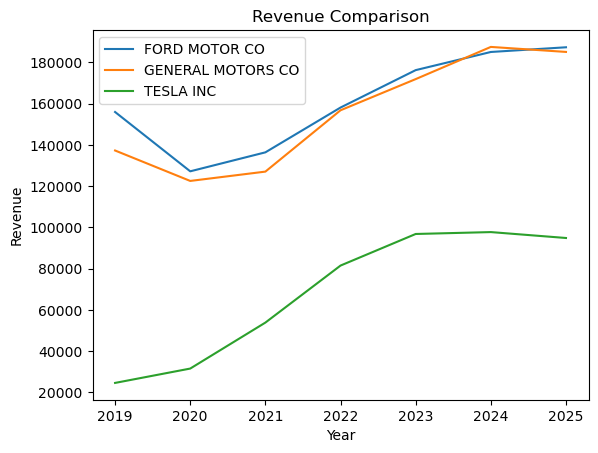

In [11]:
import matplotlib.pyplot as plt

for company in financial_data['conm'].unique():
    df = financial_data[financial_data['conm'] == company]
    plt.plot(df['fyear'], df['sale'], label=company)

plt.legend()
plt.title('Revenue Comparison')
plt.xlabel('Year')
plt.ylabel('Revenue')
plt.show()

In [12]:
financial_data.to_csv('final_analysis.csv', index=False)

In [13]:
financial_data = financial_data.sort_values(['conm', 'fyear']).copy()

financial_data['profit_margin'] = financial_data['ni'] / financial_data['sale']
financial_data['roa'] = financial_data['ni'] / financial_data['at']
financial_data['revenue_growth'] = financial_data.groupby('conm')['sale'].pct_change()
financial_data['net_income_growth'] = financial_data.groupby('conm')['ni'].pct_change()

financial_data

,conm,gvkey,fyear,sale,ni,at,revenue_growth,profit_margin,roa,net_income_growth
0,FORD MOTOR CO,004839,2019,155900.0000,47.0000,258537.0000,NaN,0.0003014753046824887748556767158,0.0001817921612767224807280969455,NaN
1,FORD MOTOR CO,004839,2020,127144.0000,-1279.0000,267261.0000,-0.1844515715202052597819114817,-0.01005946013968413767067262317,-0.004785584129371662906297589248,-28.21276595744680851063829787
2,FORD MOTOR CO,004839,2021,136341.0000,17937.0000,257035.0000,0.072335304851192348832819480,0.1315598389332629216449930688,0.06978427062462310580271169296,-15.02423768569194683346364347
3,FORD MOTOR CO,004839,2022,158057.0000,-1981.0000,255884.0000,0.159277106666373284631915565,-0.01253345312134230056245531675,-0.007741789248253114692595082147,-1.110442102915760718068796343
4,FORD MOTOR CO,004839,2023,176191.0000,4347.0000,273310.0000,0.114730761687239413629260330,0.02467208881270893518965213887,0.01590501628187772126888880758,-3.194346289752650176678445230
5,FORD MOTOR CO,004839,2024,184992.0000,5879.0000,285196.0000,0.049951473117242083874885777,0.03177975263795191143400795710,0.02061389360299583444368083704,0.352426961122613296526340005
6,FORD MOTOR CO,004839,2025,187267.0000,-8182.0000,289160.0000,0.012297829095312229718041861,-0.04369162746239326736691461923,-0.02829575321621247752109558722,-2.391733287974145262799795884
7,GENERAL MOTORS CO,005073,2019,137237.0000,6732.0000,228037.0000,NaN,0.04905382659195406486588893666,0.02952152501567728044133188912,NaN
8,GENERAL MOTORS CO,005073,2020,122485.0000,6427.0000,235194.0000,-0.1074928772852802086900762914,0.05247173123239580356778381026,0.02732637737357245507963638528,-0.0453060011883541295306001188
9,GENERAL MOTORS CO,005073,2021,127004.0000,10019.0000,244718.0000,0.036894313589419112544393191,0.07888727914081446253661302006,0.04094100147925367157299422192,0.558892173642445931227633422


In [14]:
summary_table = financial_data.groupby('conm').agg(
    avg_revenue=('sale', 'mean'),
    avg_net_income=('ni', 'mean'),
    avg_profit_margin=('profit_margin', 'mean'),
    avg_roa=('roa', 'mean'),
    avg_revenue_growth=('revenue_growth', 'mean')
).reset_index()

summary_table

,conm,avg_revenue,avg_net_income,avg_profit_margin,avg_roa,avg_revenue_growth
0,FORD MOTOR CO,160841.714286,2395.428571,0.017433,0.00938,0.037357
1,GENERAL MOTORS CO,155394.857143,7420.571429,0.049908,0.02908,0.056289
2,TESLA INC,68669.857143,6259.428571,0.073147,0.065186,0.278575


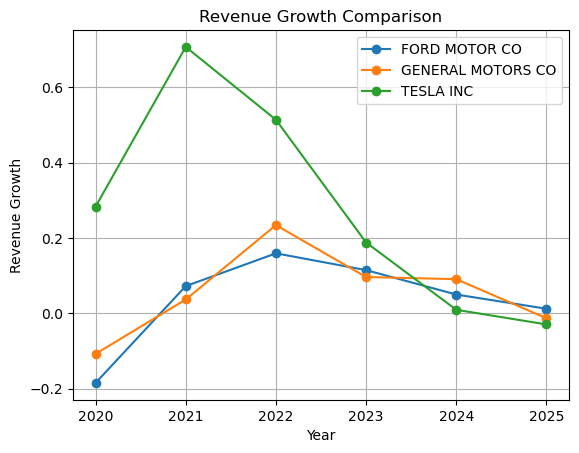

In [15]:
for company in financial_data['conm'].unique():
    df = financial_data[financial_data['conm'] == company]
    plt.plot(df['fyear'], df['revenue_growth'], marker='o', label=company)

plt.legend()
plt.title('Revenue Growth Comparison')
plt.xlabel('Year')
plt.ylabel('Revenue Growth')
plt.grid(True)
plt.show()

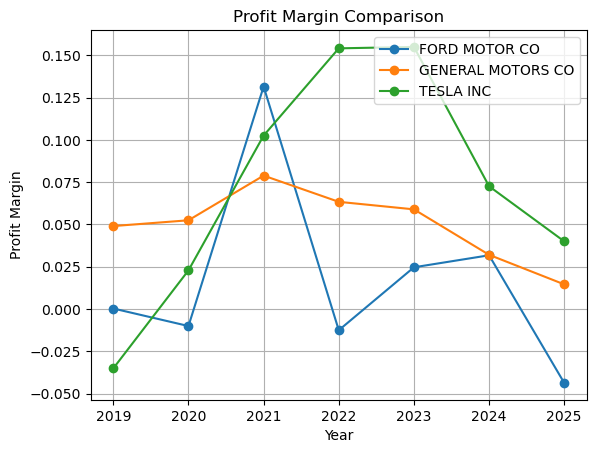

In [16]:
for company in financial_data['conm'].unique():
    df = financial_data[financial_data['conm'] == company]
    plt.plot(df['fyear'], df['profit_margin'], marker='o', label=company)

plt.legend()
plt.title('Profit Margin Comparison')
plt.xlabel('Year')
plt.ylabel('Profit Margin')
plt.grid(True)
plt.show()

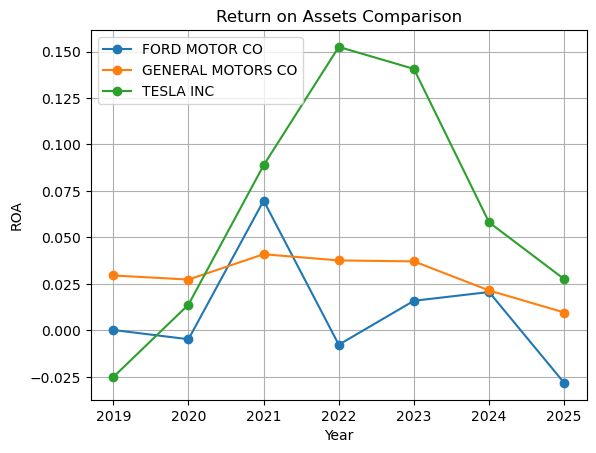

In [17]:
for company in financial_data['conm'].unique():
    df = financial_data[financial_data['conm'] == company]
    plt.plot(df['fyear'], df['roa'], marker='o', label=company)

plt.legend()
plt.title('Return on Assets Comparison')
plt.xlabel('Year')
plt.ylabel('ROA')
plt.grid(True)
plt.show()

In [18]:
latest_year = financial_data['fyear'].max()
latest_data = financial_data[financial_data['fyear'] == latest_year].copy()

latest_data['investment_score'] = (
    latest_data['profit_margin'].rank(pct=True) +
    latest_data['roa'].rank(pct=True) +
    latest_data['revenue_growth'].rank(pct=True)
)

ranking_table = latest_data[['conm', 'fyear', 'sale', 'ni', 'profit_margin', 'roa', 'revenue_growth', 'investment_score']]
ranking_table = ranking_table.sort_values('investment_score', ascending=False)

ranking_table

,conm,fyear,sale,ni,profit_margin,roa,revenue_growth,investment_score
20,TESLA INC,2025,94827.0000,3794.0000,0.04000970187815706497094709313,0.02753145726601163955125321104,-0.0293069915037363087317023237,2.333333
13,GENERAL MOTORS CO,2025,185019.0000,2697.0000,0.01457688129327258281581891590,0.009588174229604243398131425890,-0.0129266653151374825279286393,2.000000
6,FORD MOTOR CO,2025,187267.0000,-8182.0000,-0.04369162746239326736691461923,-0.02829575321621247752109558722,0.012297829095312229718041861,1.666667


In [19]:
financial_data.to_csv('final_analysis.csv', index=False)
summary_table.to_csv('summary_table.csv', index=False)
ranking_table.to_csv('investment_ranking.csv', index=False)